In [2]:
import os
import sys
p = os.path.abspath('../..')
if p not in sys.path:
    sys.path.append(p)
import waveorder as wo
import numpy as np
import tifffile as tiff
from tifffile import TiffFile
import matplotlib.pyplot as plt
from numcodecs import Blosc
import glob
import json
from waveorder.visual import plotVectorField
import zarr
from recOrder.recOrder.compute.QLIPP_compute import reconstruct_QLIPP_3D, initialize_reconstructor
from recOrder.recOrder.io.reader import MicromanagerReader
from recOrder.recOrder.io.writer import WaveorderWriter
from pycromanager.data import Dataset

In [16]:
%%time
bg_path = '/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_02_03_40x_04NA_A549/48hr_RSV/BG/'
bg_data = load_bg(bg_path, 2048, 2448)

CPU times: user 31.2 ms, sys: 60.6 ms, total: 91.8 ms
Wall time: 2.02 s


In [7]:
path = '/gpfs/CompMicro/rawdata/dragonfly/Cameron/2021_04_05_Phase_Confocal_Widefield_Comparison_6x/Confocal_Phase_Beads_2/Confocal_Phase_Beads_2_MMStack_Pos0.ome.tif'
path2 = '/gpfs/CompMicro/rawdata/dragonfly/Cameron/2021_04_05_Phase_Confocal_Widefield_Comparison_6x/Widefield_Phase_Beads_1/Widefield_Phase_Beads_1_MMStack_Pos0.ome.tif'
s0_stack = np.transpose(tiff.imread(path), (1,2,0))
s0_stack2 = np.transpose(tiff.imread(path2), (1,2,0))
np.shape(s0_stack2)

(1024, 1024, 81)

In [2]:
path = '/gpfs/CompMicro/rawdata/hummingbird/Cameron/2021_04_06_A549_Live_63x_04NA/Acq_0_Well_0_1'
data = Dataset(path)

Reading index... 34.9%       

Reading index... 82.1%       

Opening file 2 of 16...

Dataset opened                


In [3]:
def _create_stores(self, p):
    """
    extract all singlepage tiffs at each coordinate and place them in a zarr array
    coordinates are of shape = (pos, time, channel, z)
    :return:
    """
    self.log.info("")
    z = zarr.zeros(shape=(self.frames,
                          self.channels,
                          self.slices,
                          self.height,
                          self.width),
                   chunks=(1,
                           1,
                           1,
                           self.height,
                           self.width))
    for c, fn in self.coord_to_filename.items():
        if c[0] == p:
            self.log.info(f"reading coord = {c} from filename = {fn}")
            z[c[1], c[2], c[3]] = zarr.open(tiff.imread(fn, aszarr=True))
    self.positions[p] = z

In [18]:
dask_data = data.as_array()

Adding data chunk 3022 of 8125

Adding data chunk 5959 of 8125

Stacking tiles...         


Dask array opened


In [19]:
dask_data = dask_data.transpose((0,2,1,3,4))

In [25]:
test_zarr = zarr.open('/gpfs/CompMicro/rawdata/hummingbird/Cameron/2021_04_06_A549_Live_63x_04NA/test.zarr')
test_zarr.zeros('test', shape=dask_data.shape)

<zarr.core.Array '/test' (5, 25, 65, 2048, 2048) float64>

In [ ]:
dask_data.to_zarr(test_zarr['test'])

In [40]:
data.close()

AttributeError: 'int' object has no attribute 'close'

In [33]:
%%time


CPU times: user 449 µs, sys: 0 ns, total: 449 µs
Wall time: 453 µs


In [34]:
dask_data.shape

(25, 5, 65, 2048, 2048)

In [38]:
with open("/gpfs/CompMicro/rawdata/hummingbird/Cameron/2021_04_06_A549_Live_63x_04NA/Acq_0_Well_0_1/Full resolution/NDTiff.index", "rb") as index_file:
    metadata = index_file.read()
    
    
    

In [39]:
len(metadata)

842505

In [3]:
## Set Reconstruction Parameters
image_dim = (1024,1024)
wavelength = 525
swing = 0.03
N_channel = 4
NA_obj = 1.47
NA_illu = 0.53
mag = 63
N_slices = 81
z_step = 0.25
pad_z = 0
pixel_size = 6.5
bg_option = 'local_fit'
n_media = 1.512

reconstructor = initialize_reconstructor(image_dim, wavelength, swing, N_channel, NA_obj, NA_illu, mag, N_slices, z_step, pad_z, 
                                         pixel_size, bg_option = bg_option, n_media = n_media, use_gpu=False, gpu_id = 0)



Initializing Reconstructor...
Finished Initializing Reconstructor (0.40 min)


In [4]:
reg_re = 1e-4
reg_im = 1e-4
rho = 1e-5
lambda_re = 1e-3
lambda_im = 1e-3
itr = 20

In [5]:
%%time

phase3d =  reconstructor.Phase_recon_3D(s0_stack, absorption_ratio=0.0, method='Tikhonov', reg_re = reg_re, reg_im = reg_im,\
                       rho = rho, lambda_re = lambda_re, lambda_im = lambda_im, itr = itr, verbose=True)

CPU times: user 7.99 s, sys: 674 ms, total: 8.67 s
Wall time: 8.67 s


In [9]:
from numcodecs import blosc
compressor=Blosc(cname='zstd', clevel=1, shuffle=Blosc.SHUFFLE)


In [11]:
save_store = zarr.open('/gpfs/CompMicro/projects/A549/2021_02_25_40X_04NA_A549/MOCK_IFNA_48_PhaseTesting.zarr')

In [56]:
save_store.zeros('Tikhonov_norm', shape=(65,2048,2048), chunks=(65,2048,2048), dtype='float32',
                                        compressor=compressor)

<zarr.core.Array '/Tikhonov_norm' (65, 2048, 2048) float32>

In [27]:
save_store['Tikhonov_norm'] = np.transpose(phase3d_tik_norm, (2,0,1))

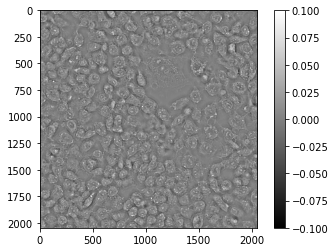

In [17]:
plt.imshow(save_store['Tikhonov1'][32], 'gray', clim=(-0.1, 0.1))
plt.colorbar()

In [17]:
%%time
# zarr_store = init_zarr_store(save_dir+'48hr_RSV')

    ret_stack, ori_stack, BF_stack, phase3D = reconstruct_QLIPP_3D(positions[pos],
                                                           bg_data, reconstructor, method = "Tikhonov",
                                                           reg_re = 1e-4, reg_im = 1e-4, rho = 1e-5, 
                                                           lambda_re = 1e-3, lambda_im = 1e-3, itr = 20)


Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.49 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.40 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.40 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.41 min)

Computing Birefringence...
Finished Computing Birefringence (1.88 min)
Computing 3d Phase...
Finished Reconstruction (2.40 min)

CPU times: user 12min 34s, sys: 8min 21s, total: 20min 55s
Wall time: 15min 51s


In [ ]:
wo.visual.image_stack_viewer_fast(retardance_stack, vrange=(0,20))

In [ ]:
wo.visual.image_stack_viewer_fast(np.transpose(phase3d,(2,1,0)))

In [ ]:
plt.figure(dpi=300)
plt.imshow(phase3d[:,:,30], 'gray')